# ASSIGNMENT: Cartoon Face Mask
## This assignment tests your ability to apply face recognition, image masks, image thresholding, video capturing and saving video feed into a video file concepts.

## TASK: Cartoonify faces in video feed from live webcam

### Steps
- 1. **Capture video** feed from webcam
- 2. **Recognize faces** in the video
- 3. **Replace/Mask the face** region with your favorite cartoon character
- 4. **Save the video** feed into a video file
- 5. Submit the following files
    - Notebook (.ipynb)
    - Video (.avi/.mp4)

# Load the Shaun the Sheep mask image

Mask loaded with shape: (192, 204, 4)


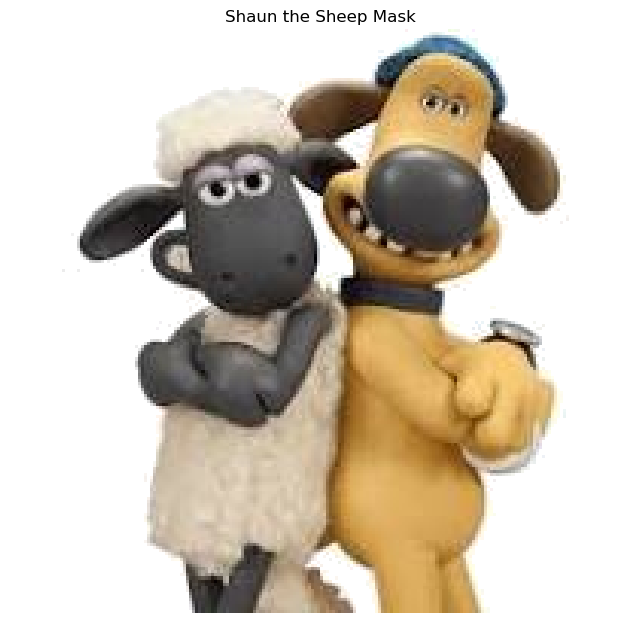

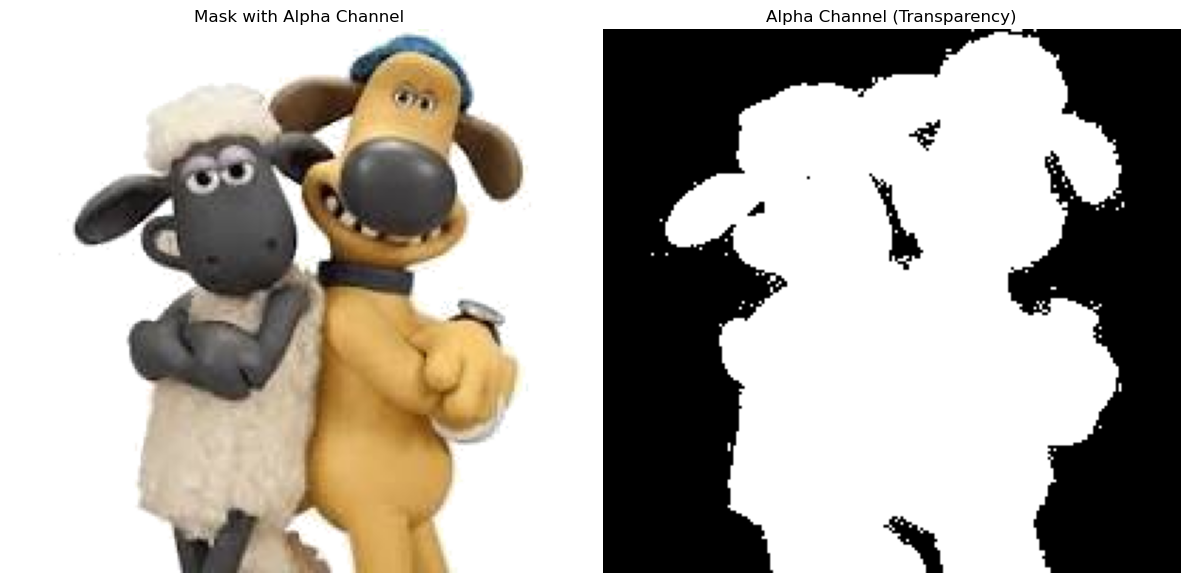

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Load the cascade classifiers
cascPathface = os.path.dirname(cv2.__file__) + "/data/haarcascade_frontalface_alt2.xml"
faceCascade = cv2.CascadeClassifier(cascPathface)

# Load the Shaun the Sheep mask image
mask_path = "Shaun_The_Sheep.jpeg"  # Make sure this file is in your working directory
if not os.path.exists(mask_path):
    raise FileNotFoundError(f"Mask file not found: {mask_path}")

mask_original = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
if mask_original is None:
    raise ValueError(f"Could not load mask image: {mask_path}")

# If the mask doesn't have an alpha channel, create one
if mask_original.shape[2] == 3:
    # Convert BGR to BGRA
    mask_original = cv2.cvtColor(mask_original, cv2.COLOR_BGR2BGRA)
    # Make white background transparent
    white = np.all(mask_original[:, :, :3] > 240, axis=2)
    mask_original[white, 3] = 0

print(f"Mask loaded with shape: {mask_original.shape}")

# Display the mask image
plt.figure(figsize=(8, 8))

# Convert BGR to RGB for matplotlib display
if mask_original.shape[2] == 4:  # BGRA image
    # For BGRA, we need to handle the alpha channel
    rgb_mask = cv2.cvtColor(mask_original, cv2.COLOR_BGRA2RGBA)
    plt.imshow(rgb_mask)
else:  # BGR image
    rgb_mask = cv2.cvtColor(mask_original, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_mask)

plt.title('Shaun the Sheep Mask')
plt.axis('off')
plt.show()

# Also display the mask with alpha channel visualization
if mask_original.shape[2] == 4:
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(mask_original, cv2.COLOR_BGRA2RGBA))
    plt.title('Mask with Alpha Channel')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask_original[:, :, 3], cmap='gray')
    plt.title('Alpha Channel (Transparency)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

- 1. **Capture video** feed from webcam
- 2. **Recognize faces** in the video
- 3. **Replace/Mask the face** region with your favorite cartoon character

In [ ]:
# Capture video from webcam
video_capture = cv2.VideoCapture(0)
if not video_capture.isOpened():
    raise IOError("Cannot open webcam")

# Get video properties
frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = video_capture.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30  # Default to 30 fps if unable to get actual fps

# Define codec and create VideoWriter object
output_file = 'shaun_sheep_mask_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'XVID' for .avi
out = cv2.VideoWriter(output_file, fourcc, fps, (frame_width, frame_height))

print(f"Video will be saved as: {os.path.abspath(output_file)}")

def overlay_mask(frame, mask, x, y, w, h):
    """Overlay the mask on the frame at the specified position"""
    # Resize mask to fit the face
    mask_resized = cv2.resize(mask, (w, h))

    # Get the region of interest on the frame
    roi = frame[y:y+h, x:x+w]

    # Create a mask from the alpha channel
    mask_alpha = mask_resized[:, :, 3] / 255.0
    mask_alpha = np.repeat(mask_alpha[:, :, np.newaxis], 3, axis=2)

    # Blend the mask with the ROI
    blended = (1.0 - mask_alpha) * roi + mask_alpha * mask_resized[:, :, :3]

    # Put the blended image back into the frame
    frame[y:y+h, x:x+w] = blended.astype('uint8')

    return frame

try:
    frame_count = 0
    while True:
        # Capture frame-by-frame
        ret, frame = video_capture.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Convert to grayscale for face detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = faceCascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(60, 60),
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        # Apply mask to each detected face
        for (x, y, w, h) in faces:
            frame = overlay_mask(frame, mask_original, x, y, w, h)

        # Write the frame to the output video
        out.write(frame)
        frame_count += 1

        # Display the resulting frame
        cv2.imshow('Shaun the Sheep Mask', frame)

        # Break the loop on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    print(f"Processed {frame_count} frames")

except Exception as e:
    print(f"Error during processing: {e}")

finally:
    # Release everything when done
    video_capture.release()
    out.release()
    cv2.destroyAllWindows()

    # Verify the output file exists
    if os.path.exists(output_file):
        file_size = os.path.getsize(output_file) / (1024 * 1024)
        print(f"Video saved successfully: {output_file} ({file_size:.2f} MB)")
    else:
        print(f"Warning: Output file {output_file} was not created")

2025-03-28 10:29:30.372 python[75616:5528982] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Video will be saved as: /Users/nahid/shaun_sheep_mask_video.mp4


2025-03-28 10:29:32.114 python[75616:5528982] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-28 10:29:32.114 python[75616:5528982] +[IMKInputSession subclass]: chose IMKInputSession_Modern


Processed 106 frames
Video saved successfully: shaun_sheep_mask_video.mp4 (2.90 MB)
